In [0]:
pip install pdpbox shap

Python interpreter will be restarted.
Python interpreter will be restarted.


In [0]:
%python
import urllib
exec(urllib.request.urlopen('https://drive.google.com/uc?export=download&id=1RBJW7od_upD0O-671cH9_RB2n5n_wLSx').read())

Initaializing completejourney database.... on first run this will take ~5min.
Loaded table: all_days
Loaded table: campaign_desc
Loaded table: campaign_table
Loaded table: causal_data
Loaded table: coupon
Loaded table: coupon_redempt
Loaded table: hh_demographic
Loaded table: product
Loaded table: tdata
Loaded table: transaction_data
Done.


In [0]:
from sklearn.linear_model import LinearRegression
import numpy as np
import pandas as pd

### The database documentation
The [full documentation](https://drive.google.com/file/d/1Ioozg-V5NJB5wDwoPXDhdZEbClABRZqd)

The ER diagram:

![databasedocumentation](https://www.nlab.org.uk/wp-content/uploads/completejourney.png)


## Task
Predict store sales for store `367,406,381`, "next day" (for now) assuming only data from these stores and the 2,500 in the sample.

So what are our steps?
* Data Exploration
* Identify (define) what a data point will conceptually represent in our machine learning task
* Define the output feature
* For each possible data point we need to create a vector (row for a pandas frame) containing the ouput and input features. Will include temporal features.
* Work out how to split these into train / valid / tests sets in a way that does not lead to information leaks in this temporal setting. 
  </br>In this demo (one would probably just directly implement the last stratergy in reality) we'll start with the evaluation stratergy: 
  </br> `Single train/validation, single held out test` then move to 
  </br> `Single train/validation, single held out test - extending the training set to sample multiple historic data points` then finally 
  </br> `Repeated train/validation, single held out test`. 
  </br> In each case we will 
    * Create a baseline, basic model and do a first evaluation
* Refine
* Interpret / understand / explain

# Task 1. Data Exploration

### Check our data. 
Do we have proper time series (no gaps)?

What are the common min/max of the time series?

In [0]:
%sql
-- CREATE a table that contains the data we are going to use in this task
-- Or at least a first guess a the data we're going to use
-- This helps from a computational point of view (makes things faster)
CREATE OR REPLACE TABLE tdata AS
SELECT * 
FROM transaction_data 
WHERE store_id IN (367,406,381)

num_affected_rows,num_inserted_rows


In [0]:
%sql
SELECT store_id
      , MIN(day)
      , MAX(day)
      , MAX(day) - MIN(day) AS expected_days
      , COUNT(DISTINCT day) days_have
      , (MAX(day) - MIN(day)) - COUNT(DISTINCT day) missing_days
FROM tdata 
GROUP BY 1

-- Common date range is 4 - 711? Depends on where the missing days fall. 

store_id,min(day),max(day),expected_days,days_have,missing_days
406,3,711,708,687,21
367,3,711,708,692,16
381,4,711,707,697,10


## Ensure we have a time series with no missing values
If we do, we'll need to deal with them &/or it might mean we not use some parts of the data if this can be justified.

To do this we need to create a table that has one row for each temporal data point we expect. 

In our context this means, for each store, a row for day 4,5,6,7,....,711.

In [0]:
%sql
-- Create a "table" that has one row per day we are interested in
-- https://spark.apache.org/docs/latest/api/sql/search.html?q=sequence
-- https://spark.apache.org/docs/latest/api/sql/search.html?q=explode
SELECT explode(sequence(4,711, 1)) day

day
4
5
6
7
8
9
10
11
12
13


In [0]:
%sql
-- JOIN with a list of unique store id's. 
-- By joining with no condition each store id is joined to create a 
-- row with all dates
-- This is the table we want, so let's create it.
CREATE OR REPLACE TABLE all_days AS
SELECT store_id, day
FROM (
  SELECT explode(sequence(4,711, 1)) day
) d
JOIN (SELECT DISTINCT store_id FROM tdata)
ON True

num_affected_rows,num_inserted_rows


In [0]:
%sql
SELECT * FROM all_days
ORDER BY day, store_id

store_id,day
367,4
381,4
406,4
367,5
381,5
406,5
367,6
381,6
406,6
367,7


In [0]:
%sql
-- Join the table that has one row for each datapoint we expect to have with the data.
-- Ensure this is a left join (where all_days is the left table) so when there is no 
-- data we get a row with NULLs where data should have been.

-- We can then create a basic visualisation using Databricks
SELECT a.store_id, a.day, t.*
FROM all_days a
LEFT JOIN tdata t
ON a.store_id = t.store_id AND a.day = t.day
WHERE t.day IS NULL

store_id,day,household_key,BASKET_ID,DAY,PRODUCT_ID,QUANTITY,SALES_VALUE,STORE_ID,RETAIL_DISC,TRANS_TIME,WEEK_NO,COUPON_DISC,COUPON_MATCH_DISC
367,383,null,null,null,null,null,null,null,null,null,null,null,null
367,411,null,null,null,null,null,null,null,null,null,null,null,null
381,22,null,null,null,null,null,null,null,null,null,null,null,null
367,6,null,null,null,null,null,null,null,null,null,null,null,null
406,56,null,null,null,null,null,null,null,null,null,null,null,null
367,404,null,null,null,null,null,null,null,null,null,null,null,null
381,46,null,null,null,null,null,null,null,null,null,null,null,null
406,389,null,null,null,null,null,null,null,null,null,null,null,null
381,8,null,null,null,null,null,null,null,null,null,null,null,null
406,37,null,null,null,null,null,null,null,null,null,null,null,null


Databricks visualization. Run in Databricks to view.

## Plotting the time series to check them visually
Aim is to check if there is anything we might not expect and/or will need to deal with.

Also, from the above missing data plot it looks like we should make the "start of our data" at 65. We'll use the plots to help confirm this is a good choice.

While here there are only three stores so we can plot them all, looking at a sample is also often very insightful if you have large amounts of data.

In [0]:
%sql
-- all together
SELECT store_id, day, COUNT(DISTINCT (store_id, basket_id))
FROM tdata
GROUP BY 1, 2

store_id,day,"count(DISTINCT named_struct(store_id, store_id, basket_id, basket_id))"
406,158,11
367,132,11
367,363,16
406,691,19
367,300,9
367,570,10
367,432,8
381,159,9
367,168,13
406,212,7


Databricks visualization. Run in Databricks to view.

In [0]:
%sql
-- just one store
SELECT store_id, day, COUNT(DISTINCT (store_id, basket_id))
FROM tdata
WHERE store_id = 367
GROUP BY 1, 2
ORDER BY day

store_id,day,"count(DISTINCT named_struct(store_id, store_id, basket_id, basket_id))"
367,3,5
367,4,2
367,5,1
367,11,3
367,12,4
367,13,5
367,14,1
367,15,9
367,16,2
367,17,3


Databricks visualization. Run in Databricks to view.

In [0]:
%sql
SELECT store_id, day, COUNT(DISTINCT (store_id, basket_id))
FROM tdata
WHERE store_id = 406
GROUP BY 1, 2
ORDER BY day

store_id,day,"count(DISTINCT named_struct(store_id, store_id, basket_id, basket_id))"
406,3,1
406,6,1
406,10,2
406,11,2
406,13,2
406,15,1
406,17,2
406,18,2
406,19,1
406,20,1


Databricks visualization. Run in Databricks to view.

In [0]:
%sql
SELECT store_id, day, COUNT(DISTINCT (store_id, basket_id))
FROM tdata
WHERE store_id = 381
GROUP BY 1, 2
ORDER BY day

store_id,day,"count(DISTINCT named_struct(store_id, store_id, basket_id, basket_id))"
381,4,1
381,6,1
381,9,1
381,10,3
381,11,4
381,12,1
381,13,1
381,14,3
381,15,1
381,17,3


Databricks visualization. Run in Databricks to view.

Ok, so that looks hard. Let's break our plan of how to tackle this down.

Our next steps are:
1. Identify (define) what a data point will conceptually represent in our machine learning task
2. Define the output feature
3. For each possible data point we need to create a vector (row for a pandas frame) containing the ouput and input features. Will include temporal features.
4. Work out how to split these into train / valid / tests sets in a way that does not lead to information leaks in this temporal setting.
5. Create a baseline
6. First evaluation!
7. Refine
8. Interpret / understand / explain

# Task 2: ML data point creation (initial feature engineering)
 

1. Identify (define) what a data point will conceptually represent in our machine learning task
2. Define the output feature
3. For each possible data point we need to create a vector (row for a pandas frame) containing the ouput and input features. Will include temporal features.
 

## Identify (define) what a data point will conceptually represent in our machine learning task

In [0]:
# Identify (define) what a data point will conceptually represent in our machine learning task

# A data point will represent the a store at a given day.
# The output feature will be the total value of all sales for a store on the given day.
# Input features are features constructed with any information that would have been known prior to the given day.

## Create a table with the output feature for each data point
Define the output feature

In [0]:
%sql
-- We therefore know we need to have one data point per (day, store_id) and that the data point must at least include the output feature.
-- Let's create that. 
-- The data here will be represented in long format
-- Don't know what long (as opposed to wide) format is? 
-- Check out this explaination: 
--                  https://towardsdatascience.com/long-and-wide-formats-in-data-explained-e48d7c9a06cb
--  or pdf version: https://drive.google.com/file/d/1-gL0Y2V6xB0CzhPoBCuXcwOs4l2V0y4C/view?usp=sharing

SELECT    day
        , store_id
        , SUM(sales_value) as sv
FROM tdata
GROUP BY 1,2

day,store_id,sv
3,367,171.44000000000003
100,406,320.96
123,367,379.90000000000003
194,381,327.5699999999999
226,367,391.25999999999993
264,406,154.07
489,381,170.98000000000005
572,406,152.39999999999995
650,367,495.9400000000003
669,381,503.9300000000002


## Add the input features
For each possible data point we need to create a vector (row for a pandas frame) containing the ouput and input features. Will include temporal features.

During the demo we'll introduce CTEs. Some resources if you want a refresher:
* [This short introduction to CTEs](https://drive.google.com/file/d/1-h4amTHvLG--TNb6rGYqEJUSaVDNstBY/view?usp=sharing)
* [The SparkSQL Guide to CTEs](https://spark.apache.org/docs/latest/sql-ref-syntax-qry-select-cte.html)

In [0]:
%sql
-- Let's extend this to now include input features!
-- We'll likely include more later, this is our first attempt.

CREATE OR REPLACE TABLE all_ml_data_pts AS
WITH sales_value_ts (
  SELECT    day
          , store_id
          , SUM( COALESCE(sales_value, 0) ) as sv -- we use COALESCE with 0 here as if we had no data for this (day, store_id) we assume they just didn't sell anything
  FROM all_days
  LEFT JOIN tdata
  USING(store_id, day)
  GROUP BY 1,2
)
SELECT *
FROM (
  SELECT day 
          , store_id
          , sv as to_predict
          , LAG(sv,1) OVER (PARTITION BY store_id ORDER BY day) as sv_1
          , LAG(sv,7) OVER (PARTITION BY store_id ORDER BY day) as sv_7
          , LAG(sv,30) OVER (PARTITION BY store_id ORDER BY day) as sv_30

          , SUM(sv) OVER (PARTITION BY store_id ORDER BY day ROWS BETWEEN 7 PRECEDING AND CURRENT ROW) - sv AS sv_w1 -- if we don't -sv it'd be an information leak!
          , SUM(sv) OVER (PARTITION BY store_id ORDER BY day ROWS BETWEEN 30 PRECEDING AND CURRENT ROW) - sv AS sv_m1 -- if we don't -sv it'd be an information leak!

          , day % 364 woy -- approximates
          , day % 30 wom -- approximates
  FROM sales_value_ts
) 
WHERE day >= 30+65 -- WHY 65? This is when our data seems to actually start 
               --WHY? as otherwise our lagged variables won't have complete information. Introduce noise.
               -- Why a subquery? must restrict AFTER any window function that looks into the past!!! Otherwise window won't have access to the data as the restriction happens before the window!!


num_affected_rows,num_inserted_rows


# Task 3: Work out how to split these into train / valid / tests sets in a way that does not lead to information leaks in this temporal setting.
We are going to start with the simplist evaluation stratergy and then move to more complex ones in this demo

We really should draw a picture!! (see whiteboard during the demo)

### Single train/validation, single held out test

In [0]:
# Recall: A data point will represent the a store at a given day, 
#         containing the prediction truth for that day (output feature) 
#         and a set of input features (only using data known prior to the given day)

# We know that creating temporal train / validation / test sets require us to select points based on specific points in time 
# (for us in this problem, reference days)

# A basic sub-task then is, given our pool of data points (table: all_ml_data_pts), create a function to select 
# X, y (input dataframe and output numpy array) for a given reference day.

def get_temporal_X_y( ref_day, debug = False ):
  sql = f"""
  SELECT *
  FROM all_ml_data_pts
  WHERE day = {ref_day}
  """
  if debug:
    print(sql)
    
  Xy = spark.sql(sql).toPandas()
  X = Xy.drop(columns = ['to_predict'])
  y = Xy.to_predict.to_numpy()
  return X, y
  

In [0]:
# Let's check it
X, y = get_temporal_X_y(711)
X, y

Out[17]: (   day  store_id    sv_1    sv_7   sv_30    sv_w1     sv_m1  woy  wom
 0  711       367  330.71  522.94  200.82  2363.95  11370.45  347   21
 1  711       381  277.86  259.96   85.67  1319.21   6818.28  347   21
 2  711       406  164.52  318.52  267.56  2180.15  11373.86  347   21,
 array([666.75, 125.86, 397.69]))

In [0]:
# Now let's create the data for a "Single train/validation, single held out test" evaluation.
# This just means selecting X,y data for three different time points:

test_ref_day = 711 

valid_ref_day = 710

train_ref_day = 709

# Why these? Test is the most recent. Hopefully more representative of the true task we'll 
# be hoping our model will perform well in when we deploy it.

# Valid is the day before (next most recent) and train is two days before (the next most recent again)

In [0]:
# Let's get them!
X_test, y_test = get_temporal_X_y(test_ref_day)
X_valid, y_valid = get_temporal_X_y(valid_ref_day)
X_train, y_train = get_temporal_X_y(train_ref_day)

#### Create a baseline, basic model and do a first evaluation

In [0]:
# Our baseline here is going to be very simple - for the prediction day, predict what was sold the day before.
# This is particularly simple for us to get as this value (the sales_value lagged by one day) was one of our input features

baseline = X_valid.sv_1.to_numpy()

In [0]:
# For a basic model we're just going to use linear regressions

from sklearn.linear_model import LinearRegression
import numpy as np


lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_valid)

# Let's evaluate based on MAE and MAPE. 
# We'll manually compute them here rather than using
# from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
# so we get per store scores rather than an overall mean.

print(f'lr: {y_pred}')
print(f'bl: {baseline}')
print(f'tr: {y_valid}')

print(f'  Baseline AE: {np.abs(baseline - y_valid)}')
print(f'       LR AE: {np.abs(y_pred - y_valid)}')

# Absolute percentage err
print(f'Baseline APE: {np.abs(baseline - y_valid) / y_valid}')
print(f'      LR APE: {np.abs(y_pred - y_valid) / y_valid}')

lr: [262.65592618 138.12346472 211.91985435]
bl: [227.53 184.2  117.45]
tr: [330.71 277.86 164.52]
  Baseline AE: [103.18  93.66  47.07]
       LR AE: [ 68.05407382 139.73653528  47.39985435]
Baseline APE: [0.3119954  0.33707623 0.28610503]
      LR APE: [0.20578172 0.50290267 0.28810998]


In [0]:
# If we wanted to see the overall we could do:
print(np.mean(np.abs(baseline - y_valid) / y_valid))
print(np.mean(np.abs(y_pred - y_valid) / y_valid))

# or
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

print(f'  Baseline AE: {mean_absolute_error(y_valid, baseline)}')
print(f'       LR AE: {mean_absolute_error(y_valid, y_pred)}')

# Absolute percentage err
print(f'  Baseline AE: {mean_absolute_percentage_error(y_valid, baseline)}')
print(f'       LR AE: {mean_absolute_percentage_error(y_valid, y_pred)}')

0.31172555402938523
0.3322647913668075
  Baseline AE: 81.30333333333341
       LR AE: 85.06348781585872
  Baseline AE: 0.31172555402938523
       LR AE: 0.3322647913668075


In [0]:
# How did we do?

# Not great. 
# How to fix? Slide Temporal Data II, ~ slide 13. 
# Using more than on reference point for training.

### Single train/validation, single held out test - extending the training set to sample multiple historic data points

In [0]:
from tqdm import tqdm
import pandas as pd
import numpy as np

test_ref_day = 711 

# let's consider our validation set
valid_ref_day = 710

# let's get our train set
train_ref_day = 709

# let's get our train set
# recall train data can be selected for any time point *historically before* your validation or test labels
train_ref_days = np.asarray( range(train_ref_day-100,train_ref_day+1) ) # range is inc. exc.

Given the only change is that train_ref_days is multiple days, we could just get the X,y dataset for each day and join them together.

This would lead to something like this:

```
X_test, y_test = get_temporal_X_y(test_ref_day)
X_valid, y_valid = get_temporal_X_y(valid_ref_day)

train_x_set = []
train_y_set = []
for day in tqdm(train_ref_days):
  X, y = get_temporal_X_y(day)
  train_x_set.append(X)
  train_y_set.append(y)

X_train = pd.concat(train_x_set)
y_train = np.concatenate(train_y_set)
```

However, the for loop over train_ref_days will be very slow.

In [0]:
# Instead let's modify the get_temporal_X_y(..) function to select points for all days we want to request

def get_temporal_X_y( ref_days, debug = False ):
  
  # if someone passes a single day that is fine
  # just change it to a list that has one element
  if isinstance(ref_days, int):
    ref_days = [ref_days] 
  
  sql = f"""
  SELECT *
  FROM all_ml_data_pts
  WHERE day IN ({ ','.join([ str(x) for x in ref_days])  })
  """
  if debug:
    print(sql)
    
  Xy = spark.sql(sql).toPandas()
  X = Xy.drop(columns = ['to_predict'])
  y = Xy.to_predict.to_numpy()
  return X, y
  

In [0]:
# Now we have our function life is simple again

X_test, y_test = get_temporal_X_y(test_ref_day)
X_valid, y_valid = get_temporal_X_y(valid_ref_day)

X_train, y_train = get_temporal_X_y(train_ref_days)

#### Create a baseline, basic model and do a first evaluation

In [0]:
# Now we have our datasets let's build a simple model and get our baseline
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_valid)
baseline = X_valid.sv_1.to_numpy()

In [0]:
# 
print(f'lr: {y_pred}')
print(f'bl: {baseline}')
print(f'tr: {y_valid}')

print(f'  Baseline AE: {np.abs(baseline - y_valid)}')
print(f'       LR AE: {np.abs(y_pred - y_valid)}')
# Absolute percentage err
print(f'Baseline APE: {np.abs(baseline - y_valid) / y_valid}')
print(f'      LR APE: {np.abs(y_pred - y_valid) / y_valid}')

lr: [371.54609117 196.45388125 323.46684776]
bl: [227.53 184.2  117.45]
tr: [330.71 277.86 164.52]
  Baseline AE: [103.18  93.66  47.07]
       LR AE: [ 40.83609117  81.40611875 158.94684776]
Baseline APE: [0.3119954  0.33707623 0.28610503]
      LR APE: [0.12348006 0.29297531 0.96612477]


In [0]:
# What happened?
# Two got better, one got worse. Perhaps, given we only have three stores we should increase our valid set size. 
# Choice - do we also increase our test size? Why not (no right answer here).

In [0]:
print(np.mean(np.abs(baseline - y_valid) / y_valid))
print(np.mean(np.abs(y_pred - y_valid) / y_valid))

0.31172555402938523
0.46086004735455743


### Repeated train/validation, single held out test

We are going to approach this problem in a step-by-step fashion to reach the function we need

1. Notice that our train/valid sets do not need to be specified by two dates, but rather one date (the date for the label for the validation set) and the number of temporal datasets (n) for the train set. Why?
  a. As we will use the strategy of taking the n temporal datasets directly preceeding the validation set. I.e. the label for the first training set will be the day before the one used for the validation, the second the two days before etc.
2. Develop a function to extract a single train/validation (sampling multiple temporal history in the training set) set based on the single reference day (make sure it works by comparing to the results we got above)
3. Extend that to include package up the data and construct a custom CV specification for correct use (recall the issues with temporal cross validation? If not, return to the slides!) in the sklearn cross_val_score and GridSearchCV Objects.

In [0]:
# Keep the single hold out set.
# We want to draw train/validation sets repeatdly.
# Draw a picture

In [0]:
# STEP 1 towards a function get Repeated train/validation, single held out test
# =====================================================

# For creating training / valid data we have days 30+65 --> 710
# Previously:
#    valid_ref_day = 710
#    train_ref_day = 709
#    train_ref_days = range(train_ref_day-100,train_ref_day+1) # range is inc. exc.


# Let's create a function to fetch data for a single train/valid set

def get_train_valid_set( ref_day = 710 ):
  
  X_valid, y_valid = get_temporal_X_y( ref_day )
  
  train_ref_days = range(ref_day-101,ref_day) # -1 compared to last time as our ref_day is the valid_ref_day, not train_ref_day
  
  X_train, y_train = get_temporal_X_y(train_ref_days)
  
  return X_train, y_train, X_valid, y_valid
  

In [0]:
# STEP 2 towards a function get Repeated train/validation, single held out test
# ==============================================================================

# GridSearchCV or cross_val_score expects a set of datapoints split into input feature (X) and corresponding output features (y)
# It also takes a parameter cv which has a list of tuples where each tuple specifies a training data set (position 0) and a validation data set (position 1) as indexs into a provide set of X and y data.

# While our previous function (above) considered our pool of data points (table: all_ml_data_pts) and selected out data points to return we could instead have instead considered the pool as one big Xy set (if the database had row identifiers / a fixed order - currently it does not) and returned the indexes to the rows we wanted for each train / valid / test set.

# If we had a function that returned indexes for each set rather than rows, we could directly use it to generate what we need for cross_val_score and GridSearchCV.

# Let's make this happen!

In [0]:
%sql
-- give our database row numbers we can use as the index
CREATE OR REPLACE TABLE all_ml_data_pts_with_index AS
SELECT row_number() OVER (ORDER BY store_id, day) - 1 as idx, * -- minus one as row_number() is 1 indexed but pandas is zero indexed
FROM all_ml_data_pts
ORDER BY store_id, day

num_affected_rows,num_inserted_rows


In [0]:
# Update our functions to return indexes
def get_temporal_X_y_idxs( ref_days, debug = False ):
  
  # if someone passes a single day that is fine
  # just change it to a list that has one element
  if isinstance(ref_days, int):
    ref_days = [ref_days] 
  
  sql = f"""
  SELECT idx
  FROM all_ml_data_pts_with_index
  WHERE day IN ({ ','.join([ str(x) for x in ref_days])  })
  """
  if debug:
    print(sql)
    
  return spark.sql(sql).toPandas().idx.to_numpy()
  

In [0]:
def get_train_valid_set_idxs( ref_day = 710 ):
  
  valid_idxs = get_temporal_X_y_idxs( ref_day )
  
  train_ref_days = range(ref_day-101,ref_day) # -1 compared to last time as our ref_day is the valid_ref_day, not train_ref_day
  
  train_idxs = get_temporal_X_y_idxs(train_ref_days )
  
  return train_idxs, valid_idxs
  

In [0]:
# Check everything is coded correctly. Use these functions to replicate
# Single train/validation, single held out test - extending the training set to sample multiple historic data points


valid_ref_day = 710

train_ref_day = 709

# Get the base dataframe
Xy = spark.sql("SELECT * FROM all_ml_data_pts_with_index ORDER BY idx").toPandas() # ORDER BY idx is cruital to ensure the dataframe matches the indexes
X = Xy.drop(columns = ['idx', 'to_predict'])
y = Xy.to_predict.to_numpy()

train_idxs, valid_idxs = get_train_valid_set_idxs( ref_day = valid_ref_day)

X_valid = X.iloc[valid_idxs]
y_valid = y[valid_idxs]
 
X_train = X.iloc[train_idxs]
y_train = y[train_idxs]  


In [0]:
# Now we have our datasets let's build a simple model and get our baseline
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_valid)
baseline = X_valid.sv_1.to_numpy()

print(f'lr: {y_pred}')
print(f'bl: {baseline}')
print(f'tr: {y_valid}')

print(f'  Baseline AE: {np.abs(baseline - y_valid)}')
print(f'       LR AE: {np.abs(y_pred - y_valid)}')
# Absolute percentage err
print(f'Baseline APE: {np.abs(baseline - y_valid) / y_valid}')
print(f'      LR APE: {np.abs(y_pred - y_valid) / y_valid}')

lr: [371.54609117 196.45388125 323.46684776]
bl: [227.53 184.2  117.45]
tr: [330.71 277.86 164.52]
  Baseline AE: [103.18  93.66  47.07]
       LR AE: [ 40.83609117  81.40611875 158.94684776]
Baseline APE: [0.3119954  0.33707623 0.28610503]
      LR APE: [0.12348006 0.29297531 0.96612477]


In [0]:
print(f'Baseline overall stores: {np.mean(np.abs(baseline - y_valid) / y_valid)}')
print(f'      LR overall stores: {np.mean(np.abs(y_pred - y_valid) / y_valid)}')

Baseline overall stores: 0.31172555402938523
      LR overall stores: 0.46086004735455743


In [0]:
from sklearn.model_selection import cross_val_score
# Ok, great, we got the same answer. Now let's do the evalation we wanted!
# Repeated train/validation, single held out test

# We will get repeated train/validation sets by starting at our reference date (which is the valid date which in turn defines the train date) and moving back one day at a time
# NOTE: we could have moved back in weekly or other blocks if we justified it!

# RECALL:
# GridSearchCV or cross_val_score expects a set of datapoints split into input feature (X) and corresponding output features (y)
# It also takes a parameter cv which has a list of tuples where each tuple specifies a training data set (position 0) and a validation data set (position 1) as indexs into a provide set of X and y data.

# Get the base dataframe
Xy = spark.sql("SELECT * FROM all_ml_data_pts_with_index ORDER BY idx").toPandas() # ORDER BY idx is cruital to ensure the dataframe matches the indexes
X = Xy.drop(columns = ['idx', 'to_predict'])
y = Xy.to_predict.to_numpy()

# define the number of validation sets to get
num_sets = 2 

all_cv_indexes = []

valid_ref_day = 710

for set_num in range(num_sets):
  train_idxs, valid_idxs = get_train_valid_set_idxs( ref_day = valid_ref_day)
  all_cv_indexes.append( (train_idxs, valid_idxs) )
  valid_ref_day -= 1

cross_val_score(lr, X, y, cv = all_cv_indexes, scoring = 'neg_mean_absolute_percentage_error')

Out[40]: array([-0.46086005, -0.87949358])

In [0]:
# Great that worked (the first value matches)! We can increase the number of validations set if we want, but for now we have everything setup! Time to move on to the next step....

# Task 4: Refine


### Now what? 
* Need to decide what steps we want to take.
* Extra features? 
* Different pre-processing?
* Different features?
* Better models?
* Better meta-parameter tunning?

## Let's start with meta-parameter tuning
Given we've gone to the effor of making train/validation set indices that work with `cross_val_score` and `GridSearchCV` this is easy...

In [0]:
# First setup our baselines
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_absolute_percentage_error

lr = LinearRegression()

lr_score_per_dataset = cross_val_score(lr, X, y, cv = all_cv_indexes, scoring = 'neg_mean_absolute_percentage_error')*-1

baseline_score_per_dataset = []
for train_idxs, valid_idxs in all_cv_indexes:
  baseline = X.iloc[valid_idxs].sv_1.to_numpy()
  y_valid = y[valid_idxs]
  baseline_score_per_dataset.append( mean_absolute_percentage_error(y_valid, baseline) )

In [0]:
# Now work on our improvement
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

grid = {
  'max_depth': [4,5,6,7,8,9,10,15,20,25, 30,35,40],
  'max_features': [1, 'log2', 'sqrt']
}

rf = RandomForestRegressor(n_estimators = 100, random_state=42)

rfgs = GridSearchCV(rf, grid, cv = all_cv_indexes, scoring = 'neg_mean_absolute_percentage_error'  )

_ = rfgs.fit(X,y)

In [0]:
print(f'Mean lr: {np.mean(lr_score_per_dataset)}')
print(f'Mean bl: {np.mean(baseline_score_per_dataset)}')
print(f'Mean rf: {np.max(rfgs.cv_results_["mean_test_score"])*-1}')
print(rfgs.best_params_)

Mean lr: 0.670176814017994
Mean bl: 0.6694084215331504
Mean rf: 0.5952667222494779
{'max_depth': 6, 'max_features': 1}


## Let's get a better (?) model

In [0]:
from lightgbm import LGBMRegressor
grid  = {
  'learning_rate': [0.05,0.1,0.15],
  'max_depth': [3,5,10],
  'feature_fraction': [0.4,0.5,0.7],
  'subsample': [0.1,0.2,0.5],
  'n_estimators': [25,50,100]
  }


In [0]:
# We set reg_lambda = None, colsample_bytree=None as you can only use one of either (feature_fraction or colsample_bytree) and (lambda_l2 or reg_lambda)
lgbm = LGBMRegressor(n_jobs = -1, lambda_l2 = 1, random_state = 42, boosting_type = 'dart', reg_lambda = None, colsample_bytree = None)
lgbm_gs = GridSearchCV(lgbm, grid, cv = all_cv_indexes, scoring = 'neg_mean_absolute_percentage_error'  )

_ = lgbm_gs.fit(X,y)
# The warnings here are ok - read them - if you don't understand why ask! A key skill is understanding what warnings you need to deal with and which you don't!
# The fix is to set: reg_lambda = None, colsample_bytree = None (as now done above)

[LightGBM] [Warning] feature_fraction is set=0.4, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.4
[LightGBM] [Warning] lambda_l2 is set=1, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1
[LightGBM] [Warning] feature_fraction is set=0.4, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.4
[LightGBM] [Warning] lambda_l2 is set=1, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1
[LightGBM] [Warning] feature_fraction is set=0.4, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.4
[LightGBM] [Warning] lambda_l2 is set=1, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1
[LightGBM] [Warning] feature_fraction is set=0.4, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.4
[LightGBM] [Warning] lambda_l2 is set=1, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1
[LightGBM] [Warning] feature_fraction is set=0.4, colsample_bytree=1.0 will be ignored. Current value: f

In [0]:
print(f'Mean lr: {np.mean(lr_score_per_dataset)}')
print(f'Mean bl: {np.mean(baseline_score_per_dataset)}')
print(f'Mean rf: {np.max(rfgs.cv_results_["mean_test_score"])*-1}')
print(f'Mean lg: {np.max(lgbm_gs.cv_results_["mean_test_score"])*-1}')
print(lgbm_gs.best_params_)

Mean lr: 0.670176814017994
Mean bl: 0.6694084215331504
Mean rf: 0.5952667222494779
Mean lg: 0.3526578686456525
{'feature_fraction': 0.4, 'learning_rate': 0.05, 'max_depth': 10, 'n_estimators': 25, 'subsample': 0.1}


In [0]:
# Ok, now I'm feeling a little better.
# Of course more optimisations are possible but you know how to do this, so we'll move on...

## Adding more features, then consider permutation importance to reduce features

In [0]:
%sql
-- How about adding more features?
-- This means returning and modifying our pool of datapoints (table: all_ml_data_points)
-- We'd then need to add the index to create table: all_ml_data_pts_with_index.
-- Instead, we'll just directly remake all_ml_data_pts_with_index.

CREATE OR REPLACE TABLE all_ml_data_pts_with_index AS
WITH sales_value_ts (
  SELECT    day
          , store_id
          , SUM( COALESCE(sales_value, 0) ) as sv -- we use COALESCE with 0 here as if we had no data for this (day, store_id) we assume they just didn't sell anything
          , COUNT(DISTINCT basket_id) as visits
  FROM all_days
  LEFT JOIN tdata
  USING(store_id, day)
  GROUP BY 1,2
)
SELECT row_number() OVER (ORDER BY store_id, day) - 1 as idx, *
FROM (
  SELECT day 
        , store_id
        , sv as to_predict
        , LAG(sv,1) OVER (PARTITION BY store_id ORDER BY day) as sv_1
        , LAG(sv,2) OVER (PARTITION BY store_id ORDER BY day) as sv_2
        , LAG(sv,3) OVER (PARTITION BY store_id ORDER BY day) as sv_3
        , LAG(sv,4) OVER (PARTITION BY store_id ORDER BY day) as sv_4
        , LAG(sv,7) OVER (PARTITION BY store_id ORDER BY day) as sv_7

        , LAG(sv,30) OVER (PARTITION BY store_id ORDER BY day) as sv_30

        , LAG(visits,1) OVER (PARTITION BY store_id ORDER BY day) as visits_1
        , LAG(visits,2) OVER (PARTITION BY store_id ORDER BY day) as visits_2

        , SUM(sv) OVER (PARTITION BY store_id ORDER BY day ROWS BETWEEN 7 PRECEDING AND CURRENT ROW) - sv AS sv_w1 -- if we don't -sv it'd be an information leak!
        , SUM(sv) OVER (PARTITION BY store_id ORDER BY day ROWS BETWEEN 30 PRECEDING AND CURRENT ROW) - sv AS sv_m1 -- if we don't -sv it'd be an information leak!

        , day % 364 woy -- approximates
        , day % 30 wom -- approximates
  FROM sales_value_ts
) 
WHERE day >= 30+65 -- WHY 65? This is when our data seems to actually start 
               --WHY? as otherwise our lagged variables won't have complete information. Introduce noise.
               -- Why a subquery? must restrict AFTER any window function that looks into the past!!! Otherwise window won't have access to the data as the restriction happens before the window!!
ORDER BY store_id, day
  

num_affected_rows,num_inserted_rows


In [0]:
# Now rerun out code

###################
# Get our data
####################
# Get the base dataframe
Xy = spark.sql("SELECT * FROM all_ml_data_pts_with_index ORDER BY idx").toPandas() # ORDER BY idx is cruital to ensure the dataframe matches the indexes
X = Xy.drop(columns = ['idx', 'to_predict'])
y = Xy.to_predict.to_numpy()

# define the number of validation sets to get
num_sets = 2 

all_cv_indexes = []

valid_ref_day = 710

for set_num in range(num_sets):
  train_idxs, valid_idxs = get_train_valid_set_idxs( ref_day = valid_ref_day)
  all_cv_indexes.append( (train_idxs, valid_idxs) )
  valid_ref_day -= 1

###################
# Run baselines
####################
lr = LinearRegression()

lr_score_per_dataset = cross_val_score(lr, X, y, cv = all_cv_indexes, scoring = 'neg_mean_absolute_percentage_error')*-1

baseline_score_per_dataset = []
for train_idxs, valid_idxs in all_cv_indexes:
  baseline = X.iloc[valid_idxs].sv_1.to_numpy()
  y_valid = y[valid_idxs]
  baseline_score_per_dataset.append( mean_absolute_percentage_error(y_valid, baseline) )
  
  
###################
# Main model
####################

grid  = {
  'learning_rate': [0.05,0.1,0.15],
  'max_depth': [3,5,10],
  'feature_fraction': [0.4,0.5,0.7],
  'subsample': [0.1,0.2,0.5],
  'n_estimators': [25,50,100]
  }

lgbm = LGBMRegressor(n_jobs = -1, lambda_l2 = 1, random_state = 42, boosting_type = 'dart', reg_lambda = None, colsample_bytree = None)
lgbm_gs = GridSearchCV(lgbm, grid, cv = all_cv_indexes, scoring = 'neg_mean_absolute_percentage_error'  )

_ = lgbm_gs.fit(X,y)

[LightGBM] [Warning] feature_fraction is set=0.4, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.4
[LightGBM] [Warning] lambda_l2 is set=1, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1
[LightGBM] [Warning] feature_fraction is set=0.4, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.4
[LightGBM] [Warning] lambda_l2 is set=1, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1
[LightGBM] [Warning] feature_fraction is set=0.4, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.4
[LightGBM] [Warning] lambda_l2 is set=1, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1
[LightGBM] [Warning] feature_fraction is set=0.4, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.4
[LightGBM] [Warning] lambda_l2 is set=1, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1
[LightGBM] [Warning] feature_fraction is set=0.4, colsample_bytree=1.0 will be ignored. Current value: f

In [0]:
###################
# Print results
####################

print(f'Mean lr: {np.mean(lr_score_per_dataset)}')
print(f'Mean bl: {np.mean(baseline_score_per_dataset)}')
print(f'Mean rf: {np.max(rfgs.cv_results_["mean_test_score"])*-1}')
print(f'Mean lg: {np.max(lgbm_gs.cv_results_["mean_test_score"])*-1}')
print(lgbm_gs.best_params_)

Mean lr: 0.7155792320241321
Mean bl: 0.6694084215331499
Mean rf: 0.5952667222494779
Mean lg: 0.3604799696454489
{'feature_fraction': 0.4, 'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 25, 'subsample': 0.1}


In [0]:
# Helper function from the prac
def print_variable_importances( feature_names, dict_in, show_top = 10 ):
  """
  Prints a table of feature importance scores.
  
  Keyword arguments
  feature_names -- list of feature names. Must have the same ordering as the 
                   scores in each instance of list_of_scores (see below)
  dict_in       -- dictionary of the form {method_name:list_of_scores} where:
                   method_name    -- string
                   list_of_scores -- list of scores, ordered in the same order
                                     as the passed feature_names
  show_top      -- number of features to show (default 10, None to print all)
  """


  # Implement the definition of None for show_top
  if show_top is None:
    show_top = len(feature_names)
  
  # Set up lists to hold the titles and score_feature tuples
  # We need a list so that they maintain fixed order as we 
  # iterate over them row-by-row.
  to_print_titles = []
  to_print_scores = []
  
  # Pair each list of scores with a copy of the feature names and sort
  # based on the variable importance score descending
  for k, v in dict_in.items():
    # zip pairs, sorted sorts, reverse orders descending
    feature_names_plus_scores = sorted( zip(v, feature_names) )
    feature_names_plus_scores.reverse()
    to_print_titles.append(k)
    to_print_scores.append(feature_names_plus_scores)
    
    
  # Print the scores
  
  # Create a list of strings to print in each header cell
  line_parts = []
  for j in range(len(to_print_titles)):
    line_parts.append('{:<38}'.format(to_print_titles[j]))
  
  # Print each header cell using a separator ' | ', adding the fixed rank column header 
  print('Rank | ' + ' | '.join( ['{:<38}'.format(x) for x in to_print_titles] ) )
  
  # Print the header underline
  print('---- + ' + ' + '.join( [ '-'*38 ]*len(to_print_titles) ) )
  
  # Print each line
  for i in range(show_top):
    # Create a list of strings to print for each row cell
    line_parts = []
    for j in range(len(to_print_titles)):
      line_parts.append(  '{:<30}: {:.4f}'.format(to_print_scores[j][i][1], to_print_scores[j][i][0]) )
    # Print the row by:
    # (1) joining each row cell using a separator ' | '
    # (2) adding the fixed rank column header 
    print( '{:<4} | '.format(str(i)) + ' | '.join(line_parts) )
      
    
 

In [0]:
from sklearn.inspection import permutation_importance
from sklearn.metrics import make_scorer

feature_importance_scores = {}

# Let's build a new lightgbm estimator using the best parameters
lgbm = LGBMRegressor(n_jobs = -1, lambda_l2 = 1, random_state = 42, boosting_type = 'dart', feature_fraction= 0.4, learning_rate = 0.05, max_depth= 5, n_estimators= 25, subsample= 0.1)

scores = []
overall_results_sum = np.zeros(X.shape[1])

for train_idxs, valid_idxs in all_cv_indexes:
  X_valid = X.iloc[valid_idxs]
  y_valid = y[valid_idxs]

  X_train = X.iloc[train_idxs]
  y_train = y[train_idxs]
  
  lgbm.fit(X_train, y_train)
  
  perm_results = permutation_importance(lgbm, X_valid, y_valid, n_repeats = 50, scoring = 'neg_mean_absolute_percentage_error'  )
  overall_results_sum += perm_results.importances_mean
  scores.append( mean_absolute_percentage_error(y_valid,lgbm.predict(X_valid) ) ) 


method_name = 'Perm cv (for selection) LGBM ({:.2f})'.format(np.mean(scores))

feature_importance_scores[method_name] = overall_results_sum / len(all_cv_indexes)



[LightGBM] [Warning] feature_fraction is set=0.4, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.4
[LightGBM] [Warning] lambda_l2 is set=1, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1


In [0]:
print_variable_importances( X.columns, feature_importance_scores, show_top = None )

Rank | Perm cv (for selection) LGBM (0.36)   
---- + --------------------------------------
0    | store_id                      : 0.0165
1    | sv_3                          : 0.0136
2    | sv_7                          : 0.0111
3    | sv_2                          : 0.0029
4    | woy                           : 0.0000
5    | wom                           : 0.0000
6    | day                           : 0.0000
7    | visits_2                      : -0.0002
8    | sv_4                          : -0.0006
9    | visits_1                      : -0.0030
10   | sv_30                         : -0.0055
11   | sv_1                          : -0.0092
12   | sv_m1                         : -0.0250
13   | sv_w1                         : -0.0256


In [0]:
# Now could do manual feature elimination or RFE. 
# For time, I'm going to do manual. This is probably not a great idea as it looks like there are a lot of interactions going on...

In [0]:
X_reduced = X.drop(columns = ['sv_w1','sv_m1', 'sv_30', 'day', 'wom', 'visits_1', 'visits_2'])

lgbm = LGBMRegressor(n_jobs = -1, lambda_l2 = 1, random_state = 42, boosting_type = 'dart', feature_fraction= 0.4, learning_rate = 0.05, max_depth= 5, n_estimators= 25, subsample= 0.1)

fold_results = cross_val_score(lgbm, X_reduced, y, cv = all_cv_indexes, scoring = 'neg_mean_absolute_percentage_error')
print(f'Mean result: {np.mean(fold_results)}')

[LightGBM] [Warning] feature_fraction is set=0.4, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.4
[LightGBM] [Warning] lambda_l2 is set=1, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1
[LightGBM] [Warning] feature_fraction is set=0.4, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.4
[LightGBM] [Warning] lambda_l2 is set=1, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1
Mean result: -0.3325018825277911


In [0]:
# Ok, so slight improvement, let's move on.

# Task 5: Compute the Expected predictive performance on new data
Using one time slice here is somewhat tenuous here given we only have three stores, but will do for this demo.

In [0]:
test_idxs = get_temporal_X_y_idxs( 711 )

X_test = X_reduced.iloc[test_idxs]
y_test = y[test_idxs]

X_train = X_reduced.drop(test_idxs, axis=0)
y_train = np.delete(y, test_idxs, axis=0)

lgbm.fit(X_train, y_train)

[LightGBM] [Warning] feature_fraction is set=0.4, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.4
[LightGBM] [Warning] lambda_l2 is set=1, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1
Out[60]: LGBMRegressor(boosting_type='dart', feature_fraction=0.4, lambda_l2=1,
              learning_rate=0.05, max_depth=5, n_estimators=25, random_state=42,
              subsample=0.1)

In [0]:
mean_absolute_percentage_error(y_test,lgbm.predict(X_test) )

Out[61]: 0.4922939490607962

## Understanding the model, PDP and SHAP

In [0]:
print(X_reduced.columns)

Index(['store_id', 'sv_1', 'sv_2', 'sv_3', 'sv_4', 'sv_7', 'woy'], dtype='object')


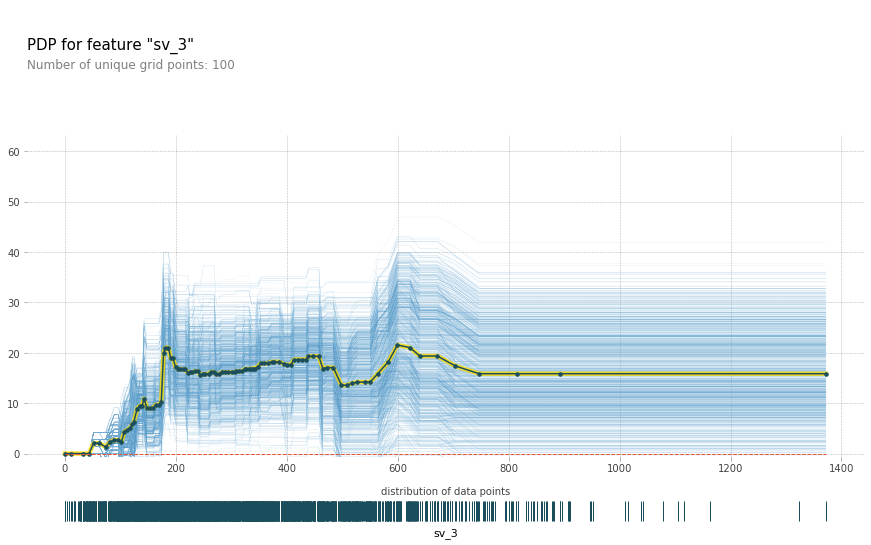

In [0]:
from pdpbox import pdp, get_dataset, info_plots
pdp_obj = pdp.pdp_isolate(
    model=lgbm, dataset=X_reduced, model_features=X_reduced.columns, feature='sv_3',num_grid_points = 100
)

fig, axes = pdp.pdp_plot(pdp_obj, 'sv_3', plot_lines=True, frac_to_plot=0.5, plot_pts_dist=True)

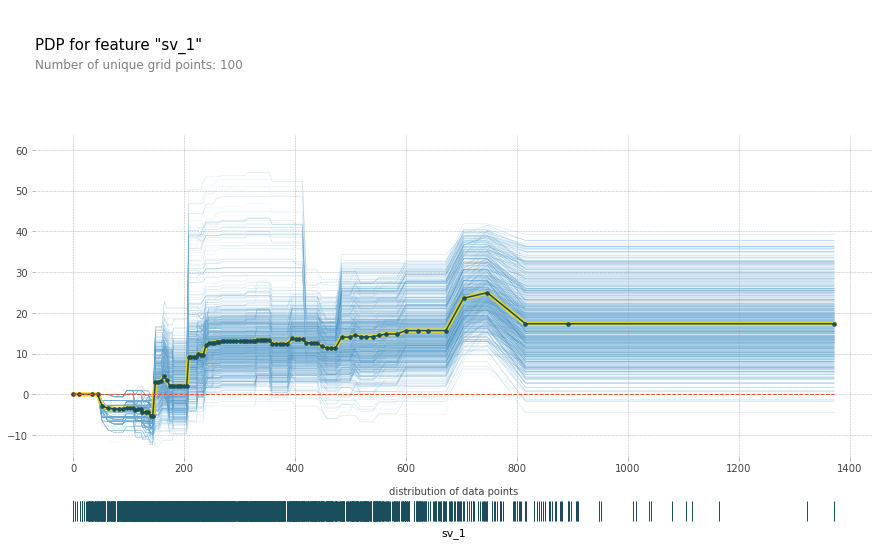

In [0]:

pdp_obj = pdp.pdp_isolate(
    model=lgbm, dataset=X_reduced, model_features=X_reduced.columns, feature='sv_1',num_grid_points = 100
)

fig, axes = pdp.pdp_plot(pdp_obj, 'sv_1', plot_lines=True, frac_to_plot=0.5, plot_pts_dist=True)

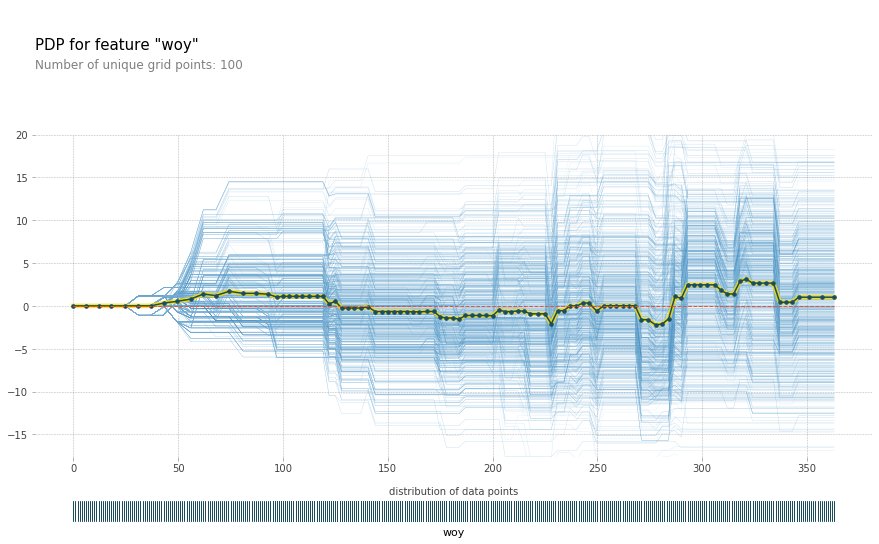

In [0]:
pdp_obj = pdp.pdp_isolate(
    model=lgbm, dataset=X_reduced, model_features=X_reduced.columns, feature='woy',num_grid_points = 100
)

fig, axes = pdp.pdp_plot(pdp_obj, 'woy', plot_lines=True, frac_to_plot=0.5, plot_pts_dist=True)

Out[76]: (<Figure size 1800x720 with 3 Axes>,
 {'title_ax': <matplotlib.axes._subplots.AxesSubplot at 0x7f801876e280>,
  'pdp_inter_ax': <matplotlib.axes._subplots.AxesSubplot at 0x7f8018978b50>})

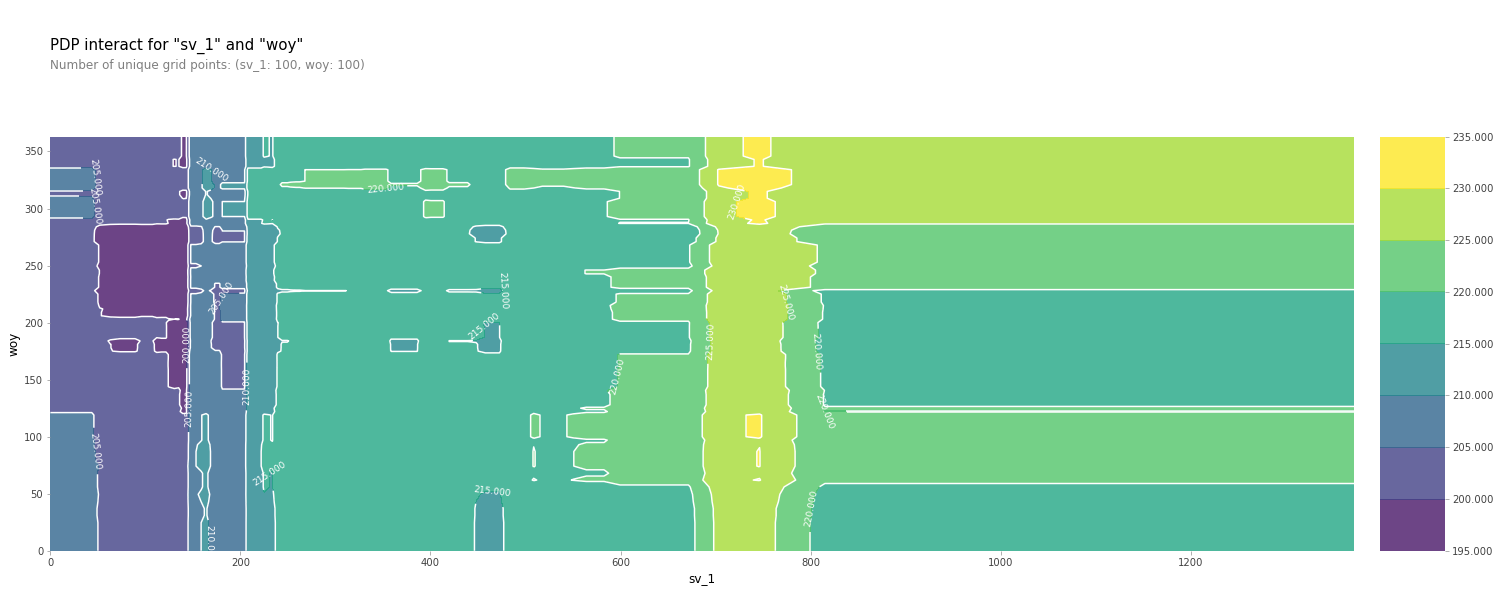

In [0]:
feats = ['sv_1', 'woy']
p = pdp.pdp_interact(lgbm, X_reduced, X_reduced.columns, feats,num_grid_points = [100,100])
pdp.pdp_interact_plot(p, feats, figsize = (25,10))

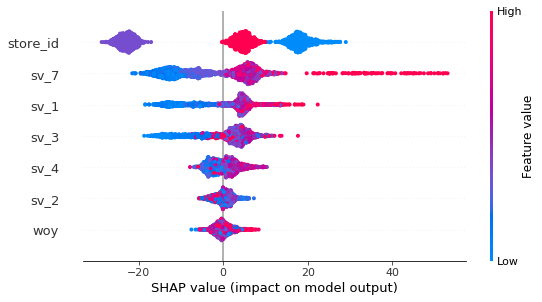

In [0]:
import shap
shap_values = shap.TreeExplainer(lgbm).shap_values(X_reduced)
shap.summary_plot(shap_values, X_reduced)